In [ ]:
# pip install kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

🛍️ Classwork: Customer Persona Discovery🛍️ Դասարանական աշխատանք․ Հաճախորդների տիպերի բացահայտումDataset: Mall_Customers.csv (Features: Annual Income, Spending Score)English Instructions:Exploration: Load the dataset and select the numerical features: Annual Income (k$) and Spending Score (1-100).The Elbow Method: Calculate the WCSS (Within-Cluster Sum of Squares) for a range of 1 to 11 clusters. Plot the results and identify the "Elbow" point to determine the optimal $K$.K-Means Clustering: Create a K-Means model using the optimal $K$ found. Fit it to the raw data and assign a Cluster_Raw label to each customer.Dimensionality Reduction (PCA): Use Principal Component Analysis (PCA) to reduce the data to 2 components. Perform K-Means clustering on these components and assign a Cluster_PCA label.Visualization (t-SNE): Use t-SNE to project the high-dimensional data into a 2D space.Comparison: Create two scatter plots:One showing clusters found on raw data (visualized via PCA).One showing clusters found on the PCA components (visualized via t-SNE).


Հայերեն հրահանգներ:Ուսումնասիրություն: Բեռնեք տվյալների բազան և ընտրեք թվային հատկանիշները՝ Annual Income (k$) և Spending Score (1-100):Անկյունի մեթոդ (Elbow Method): Հաշվարկեք WCSS-ը (Within-Cluster Sum of Squares) 1-ից 11 կլաստերների միջակայքի համար: Գծեք արդյունքները և գտեք «անկյունը» (Elbow), որոշելու համար կլաստերների օպտիմալ քանակը ($K$):K-Means Կլաստերավորում: Ստեղծեք K-Means մոդել՝ օգտագործելով գտնված օպտիմալ $K$-ն: Մարզեք այն հում տվյալների վրա և յուրաքանչյուր հաճախորդին տվեք Cluster_Raw պիտակը:Չափողականության նվազեցում (PCA): Օգտագործեք PCA (Գլխավոր բաղադրիչների վերլուծություն) տվյալները 2 բաղադրիչի վերածելու համար: Կատարեք K-Means կլաստերավորում այդ բաղադրիչների հիման վրա և տվեք Cluster_PCA պիտակը:Վիզուալիզացիա (t-SNE): Օգտագործեք t-SNE ալգորիթմը՝ բարձր չափողականությամբ տվյալները 2D տարածության մեջ պրոյեկտելու համար:Համեմատություն: Ստեղծեք երկու scatter plot.Մեկը, որը ցույց է տալիս հում տվյալների վրա գտնված կլաստերները (PCA-ի միջոցով վիզուալիզացված):Մյուսը, որը ցույց է տալիս PCA բաղադրիչների վրա գտնված կլաստերները (t-SNE-ի միջոցով վիզուալիզացված):

In [50]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)', 'Cluster_Raw', 'Cluster_PCA'],
      dtype='object')

In [39]:
df.describe().round(1)

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Gender_Numeric,Cluster
count,200.0,200.0,200.0,200.0,200.0,200.0
mean,100.5,38.8,60.6,50.2,0.4,2.0
std,57.9,14.0,26.3,25.8,0.5,1.5
min,1.0,18.0,15.0,1.0,0.0,0.0
25%,50.8,28.8,41.5,34.8,0.0,0.0
50%,100.5,36.0,61.5,50.0,0.0,2.0
75%,150.2,49.0,78.0,73.0,1.0,3.0
max,200.0,70.0,137.0,99.0,1.0,4.0


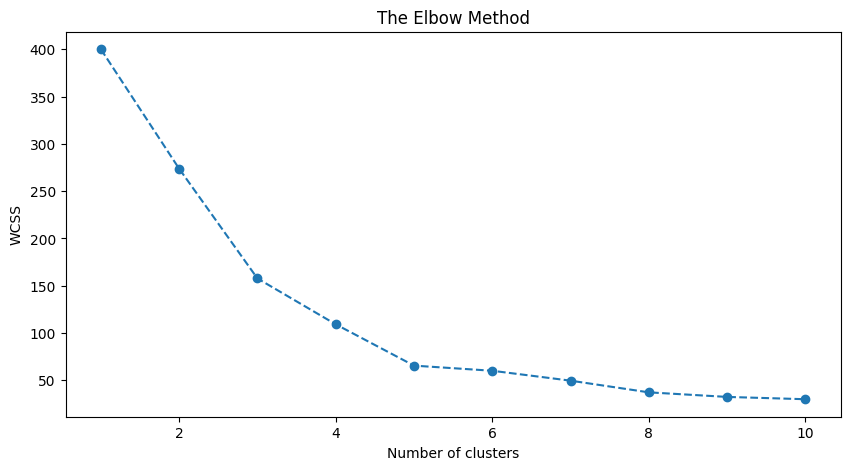

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


df = pd.read_csv(path+'/Mall_Customers.csv')
X = df.iloc[:, [3, 4]].values # Income and Spending Score


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()


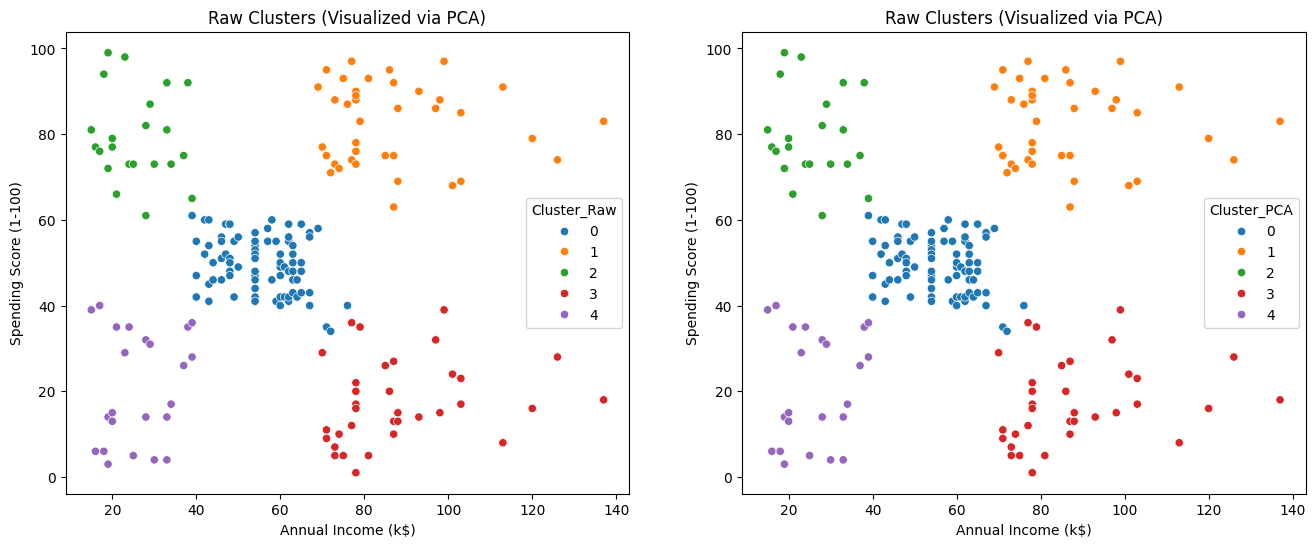

In [56]:


optimal_k = 5
kmeans_raw = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster_Raw'] = kmeans_raw.fit_predict(X_scaled)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster_PCA'] = kmeans_pca.fit_predict(X_pca)


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Raw Clusters on PCA projection
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['Cluster_Raw'], palette='tab10', ax=ax1)
ax1.set_title('Raw Clusters (Visualized via PCA)')

# Plot 1: Raw Clusters on PCA projection
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], hue=df['Cluster_PCA'], palette='tab10', ax=ax2)
ax2.set_title('Raw Clusters (Visualized via PCA)')

plt.show()

In [53]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Raw,Cluster_PCA
0,1,Male,19,15,39,4,4
1,2,Male,21,15,81,2,2
2,3,Female,20,16,6,4,4
3,4,Female,23,16,77,2,2
4,5,Female,31,17,40,4,4
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,1
196,197,Female,45,126,28,3,3
197,198,Male,32,126,74,1,1
198,199,Male,32,137,18,3,3


In [45]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Calculate metrics
sil_score = silhouette_score(X_scaled, df['Cluster_PCA'])
db_index = davies_bouldin_score(X_scaled, df['Cluster_PCA'])

print(f"--- Clustering Performance ---")
print(f"Silhouette Score: {sil_score:.3f} (Closer to 1 is better)")
print(f"Davies-Bouldin Index: {db_index:.3f} (Lower is better)")

--- Clustering Performance ---
Silhouette Score: 0.555 (Closer to 1 is better)
Davies-Bouldin Index: 0.572 (Lower is better)



--- Cluster Metric Ranges ---
            Annual Income (k$)          Spending Score (1-100)        
                          mean min  max                   mean min max
Cluster_PCA                                                           
0                    55.296296  39   76              49.518519  34  61
1                    86.538462  69  137              82.128205  63  97
2                    25.727273  15   39              79.363636  61  99
3                    88.200000  70  137              17.114286   1  39
4                    26.304348  15   39              20.913043   3  40


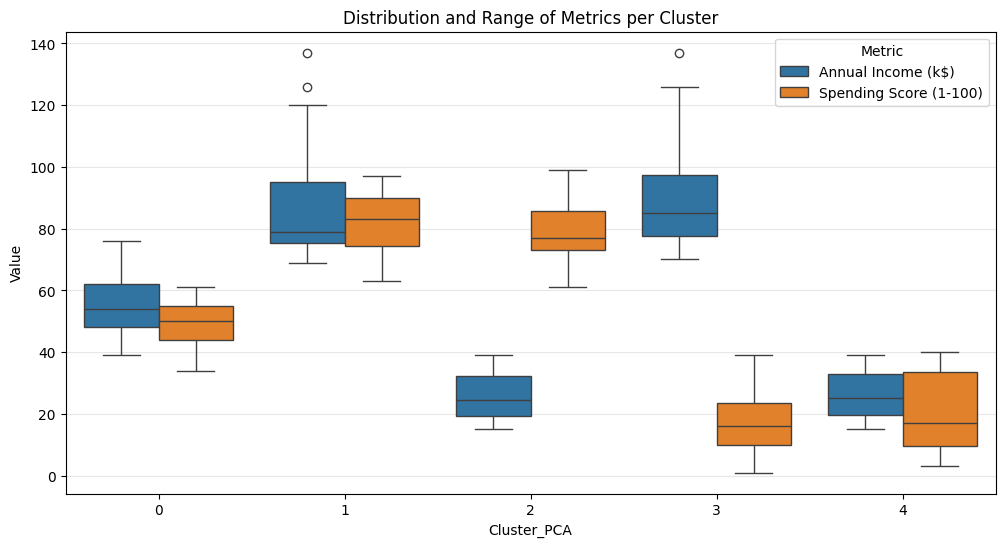

In [58]:
# Select original features and the cluster label
analysis_cols = ['Annual Income (k$)', 'Spending Score (1-100)', 'Cluster_PCA']

# Create a summary table for ranges and averages
cluster_summary = df[analysis_cols].groupby('Cluster_PCA').agg(['mean', 'min', 'max'])

# Formatting for readability
print("\n--- Cluster Metric Ranges ---")
print(cluster_summary)

# Optional: Melt the data for better visualization of ranges
df_melted = df.melt(id_vars='Cluster_PCA', 
                    value_vars=['Annual Income (k$)', 'Spending Score (1-100)'],
                    var_name='Metric', value_name='Value')

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x='Cluster_PCA', y='Value', hue='Metric')
plt.title('Distribution and Range of Metrics per Cluster')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [60]:
cluster_summary.round(2)

Annual Income (k$)          Spending Score (1-100)        
                          mean min  max                   mean min max
Cluster_PCA                                                           
0                        55.30  39   76                  49.52  34  61
1                        86.54  69  137                  82.13  63  97
2                        25.73  15   39                  79.36  61  99
3                        88.20  70  137                  17.11   1  39
4                        26.30  15   39                  20.91   3  40

# Gender and Age added

--- Cluster Profiles & Ranges ---
               Age           Gender Annual Income (k$)           \
              mean min max <lambda>               mean min  max   
Cluster                                                           
0        56.470588  37  70     Male          46.098039  19   75   
1        39.500000  19  59     Male          85.150000  71  137   
2        28.690476  18  40     Male          60.904762  15  137   
3        37.897959  23  56   Female          82.122449  54  126   
4        27.315789  18  43   Female          38.842105  16   65   

        Spending Score (1-100)          
                          mean min max  
Cluster                                 
0                    39.313725   3  60  
1                    14.050000   1  36  
2                    70.238095  35  97  
3                    54.448980   7  95  
4                    56.210526   6  99  


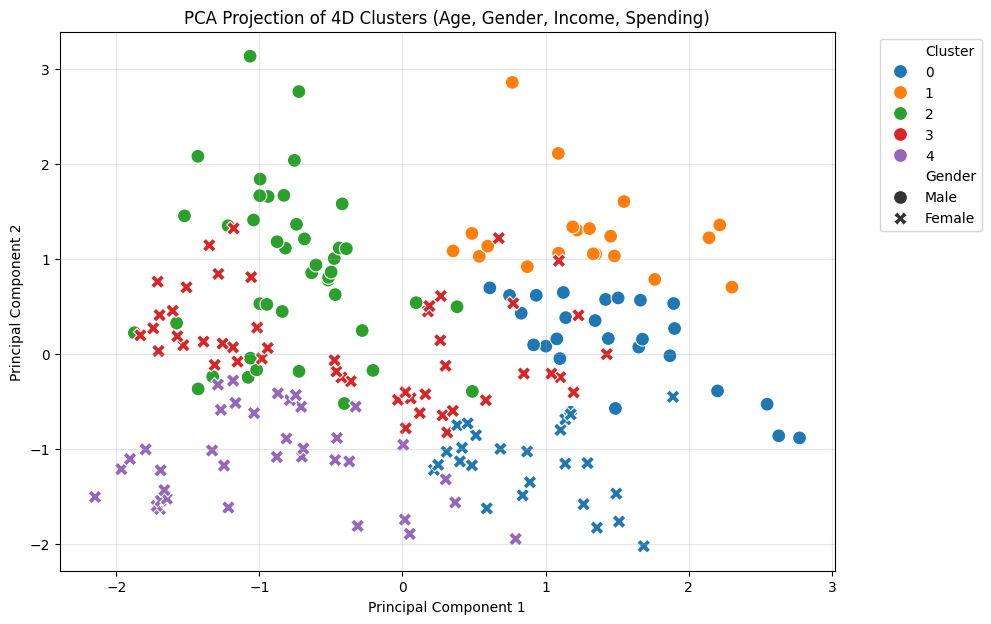

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Load and Pre-process
df = pd.read_csv(path +'/Mall_Customers.csv')

# Convert Gender to numeric: Male = 1, Female = 0
df['Gender_Numeric'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Select all features for clustering
features = ['Age', 'Gender_Numeric', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

# 2. Scaling (Essential when mixing Age, Gender, and Income)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. K-Means Clustering
# With 4 features, the "optimal K" might shift, but let's stick with 5 or 6 for comparison
optimal_k = 5 
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# 4. Post-Clustering Analysis: Metric Ranges
# We use the original dataframe to get human-readable ranges
cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'min', 'max'],
    'Gender': lambda x: x.mode()[0], # Most frequent gender in cluster
    'Annual Income (k$)': ['mean', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'min', 'max']
})

print("--- Cluster Profiles & Ranges ---")
print(cluster_profile)

# 5. Visualization via PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['Cluster'], 
                palette='tab10', style=df['Gender'], s=100)
plt.title('PCA Projection of 4D Clusters (Age, Gender, Income, Spending)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.grid(True, alpha=0.3)
plt.show()

In [61]:

cluster_profile

Age           Gender Annual Income (k$)           \
              mean min max <lambda>               mean min  max   
Cluster                                                           
0        56.470588  37  70     Male          46.098039  19   75   
1        39.500000  19  59     Male          85.150000  71  137   
2        28.690476  18  40     Male          60.904762  15  137   
3        37.897959  23  56   Female          82.122449  54  126   
4        27.315789  18  43   Female          38.842105  16   65   

        Spending Score (1-100)          
                          mean min max  
Cluster                                 
0                    39.313725   3  60  
1                    14.050000   1  36  
2                    70.238095  35  97  
3                    54.448980   7  95  
4                    56.210526   6  99

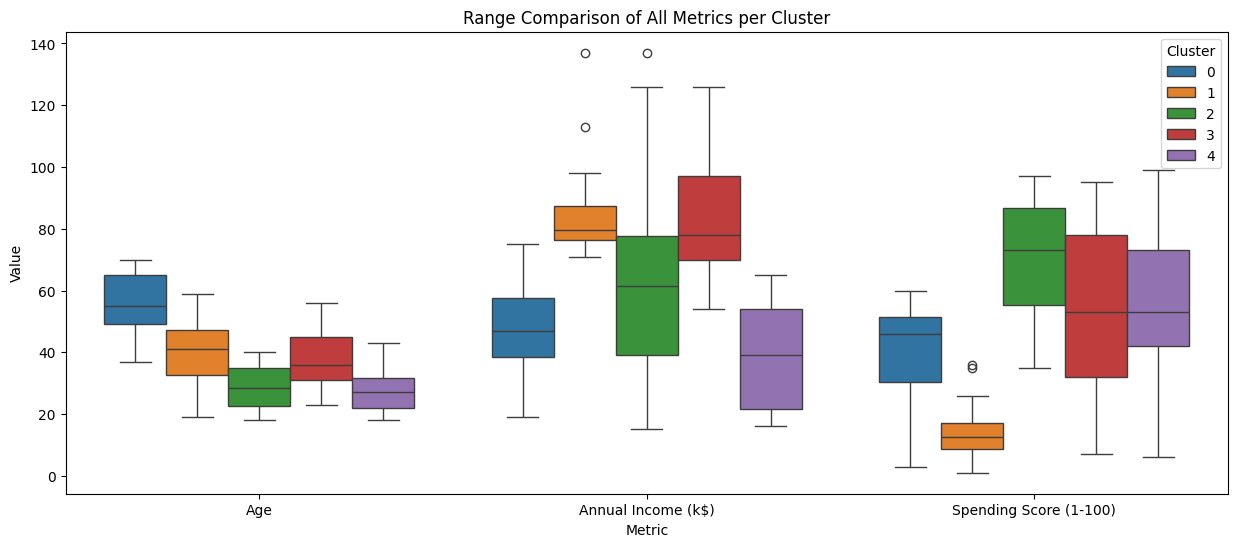

In [32]:
# Melt the data for a combined boxplot view
df_plot = df.melt(id_vars='Cluster', value_vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])

plt.figure(figsize=(15, 6))
sns.boxplot(data=df_plot, x='variable', y='value', hue='Cluster', palette='tab10')
plt.title('Range Comparison of All Metrics per Cluster')
plt.ylabel('Value')
plt.xlabel('Metric')
plt.show()